# Projeto A3 — Mineração
**Dataset:** Spotify Tracks — 81.191 músicas (após limpeza)  
**Disciplina:** Inteligência Artificial  
**Problema:** *"O que faz uma música ser popular? É possível prever a popularidade?"*

---

### Algoritmos aplicados nesta fase

| # | Algoritmo | Família (Edital) | Objetivo |
|---|---|---|---|
| 1 | **K-Means Clustering** | Agrupamento | Descobrir perfis sonoros naturais nas músicas |
| 2 | **Árvore de Decisão** | Classificação | Classificar músicas por categoria de popularidade |
| 3 | **Regressão Linear** | Regressão | Prever o score numérico de popularidade (0–100) |

---

### Arquivos necessários (da pasta Resultados no Drive)
| Arquivo | Usado por |
|---|---|
| `X_train.csv` | Todos os 3 algoritmos |
| `X_test.csv` | Árvore de Decisão e Regressão |
| `y_classificacao_train.csv` | Árvore de Decisão |
| `y_classificacao_test.csv` | Árvore de Decisão |
| `y_regressao_train.csv` | Regressão Linear |
| `y_regressao_test.csv` | Regressão Linear |

---
##Configuração Inicial
Montamos o Google Drive, importamos as bibliotecas e carregamos todos os arquivos gerados na Fase 2.

In [ ]:
# Montando o Google Drive
from google.colab import drive
drive.mount('/content/drive')

print('Google Drive montado!')

Mounted at /content/drive
Google Drive montado!


In [ ]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Algoritmos
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LinearRegression

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score,
    silhouette_score
)

# Validação cruzada
from sklearn.model_selection import cross_val_score

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


In [ ]:
# Carregando os arquivos da Fase 2
PASTA = '/content/drive/MyDrive/A3 2026/Resultados'

X_train = pd.read_csv(f'{PASTA}/X_train.csv')
X_test  = pd.read_csv(f'{PASTA}/X_test.csv')

y_clf_train = pd.read_csv(f'{PASTA}/y_classificacao_train.csv').squeeze()
y_clf_test  = pd.read_csv(f'{PASTA}/y_classificacao_test.csv').squeeze()

y_reg_train = pd.read_csv(f'{PASTA}/y_regressao_train.csv').squeeze()
y_reg_test  = pd.read_csv(f'{PASTA}/y_regressao_test.csv').squeeze()

print('Arquivos carregados com sucesso!')
print(f'   X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'   Features disponíveis: {list(X_train.columns)}')

Arquivos carregados com sucesso!
   X_train: (64952, 15) | X_test: (16239, 15)
   Features disponíveis: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min', 'explicit', 'key', 'mode', 'time_signature', 'track_genre_encoded']


---
---
#ALGORITMO 1 — K-Means Clustering
### Família: Agrupamento (não supervisionado)

---
## O que é o K-Means?
O K-Means é um algoritmo de **agrupamento não supervisionado** — ele não recebe rótulos, não sabe o que é popular ou impopular. Ele apenas observa os atributos sonoros das músicas e **descobre sozinho grupos com características similares**.

### Por que usar no nosso problema?
Queremos responder: *"Existem perfis sonoros naturais nas músicas do Spotify?"*  
Por exemplo: músicas acústicas e calmas formam um grupo? Músicas energéticas e dançantes formam outro?

### Como funciona?
1. Define **K centroides** aleatórios (um por grupo)
2. Cada música é atribuída ao centroide mais próximo
3. Os centroides são recalculados como a média do grupo
4. Repete até convergir

### Métrica de avaliação: Silhouette Score
Varia de **-1 a 1**. Quanto mais próximo de 1, melhor a separação entre os grupos.

### Passo 1 — Encontrar o número ideal de clusters (Método do Cotovelo)
Antes de rodar o K-Means, precisamos definir **quantos grupos (K)** faz sentido.  
O método do cotovelo testa vários valores de K e mede a **inércia** (soma das distâncias ao centroide).  
O K ideal fica no "cotovelo" do gráfico — onde a redução de inércia começa a desacelerar.

Calculando inércia e Silhouette para K = 2 a 10...
  K=2 | Inércia: 2854914 | Silhouette: 0.6072
  K=3 | Inércia: 1344730 | Silhouette: 0.5492
  K=4 | Inércia: 752471 | Silhouette: 0.5463
  K=5 | Inércia: 536359 | Silhouette: 0.5068
  K=6 | Inércia: 421935 | Silhouette: 0.4685
  K=7 | Inércia: 355347 | Silhouette: 0.4384
  K=8 | Inércia: 295138 | Silhouette: 0.4220
  K=9 | Inércia: 262577 | Silhouette: 0.3911
  K=10 | Inércia: 234407 | Silhouette: 0.3737


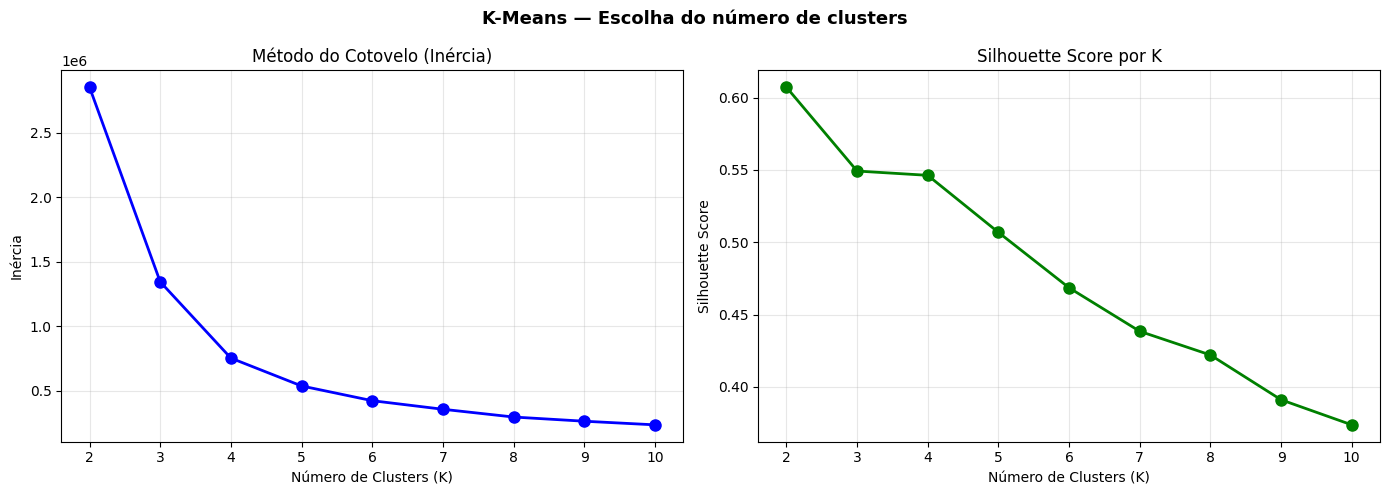


 Gráfico do cotovelo gerado.


In [ ]:
# Método do Cotovelo para encontrar o K ideal
# Usamos uma amostra para agilizar o cálculo (K-Means é custoso em datasets grandes)
amostra = X_train.sample(n=10000, random_state=42)

inercias = []
silhouettes = []
K_range = range(2, 11)

print('Calculando inércia e Silhouette para K = 2 a 10...')
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(amostra)
    inercias.append(km.inertia_)
    sil = silhouette_score(amostra, km.labels_, sample_size=2000, random_state=42)
    silhouettes.append(sil)
    print(f'  K={k} | Inércia: {km.inertia_:.0f} | Silhouette: {sil:.4f}')

# Gráficos do cotovelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K-Means — Escolha do número de clusters', fontsize=13, fontweight='bold')

axes[0].plot(K_range, inercias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Método do Cotovelo (Inércia)')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score por K')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_cotovelo.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Gráfico do cotovelo gerado.')

### Passo 2 — Treinando o K-Means com K escolhido
Com base no gráfico do cotovelo, escolhemos o K onde a curva de inércia "dobra" — indicando que adicionar mais clusters não traz ganho significativo.

**Decisão:** Usaremos **K=4**, pois corresponde intuitivamente a 4 perfis sonoros esperados:  
acústico/calmo, pop/dançante, eletrônico/energético e experimental/instrumental.

In [ ]:
# Treinando o K-Means com K=4
K_ESCOLHIDO = 4

kmeans = KMeans(n_clusters=K_ESCOLHIDO, random_state=42, n_init=10)
kmeans.fit(X_train)

# Atribuindo clusters ao conjunto de treino
X_train_kmeans = X_train.copy()
X_train_kmeans['cluster'] = kmeans.labels_

# Silhouette Score final
sil_final = silhouette_score(X_train.sample(5000, random_state=42),
                              kmeans.predict(X_train.sample(5000, random_state=42)))

print(f'K-Means treinado com K={K_ESCOLHIDO}')
print(f'   Inércia final:      {kmeans.inertia_:.2f}')
print(f'   Silhouette Score:   {sil_final:.4f}  (quanto mais próximo de 1, melhor)')
print(f'\nDistribuição das músicas por cluster:')
print(X_train_kmeans['cluster'].value_counts().sort_index())

K-Means treinado com K=4
   Inércia final:      4908257.28
   Silhouette Score:   0.5432  (quanto mais próximo de 1, melhor)

Distribuição das músicas por cluster:
cluster
0    16551
1    13993
2    15456
3    18952
Name: count, dtype: int64


### Passo 3 — Interpretando os clusters
Agora analisamos **o que cada cluster representa** musicalmente, calculando a média de cada feature por grupo.

Perfil médio dos clusters:
         danceability  energy  acousticness  valence  instrumentalness  tempo  \
cluster                                                                         
0               0.550   0.697         0.250    0.440             0.159  0.517   
1               0.560   0.584         0.412    0.499             0.166  0.488   
2               0.552   0.632         0.337    0.465             0.157  0.501   
3               0.572   0.621         0.333    0.457             0.241  0.499   

         loudness  
cluster            
0           0.780  
1           0.743  
2           0.757  
3           0.747  


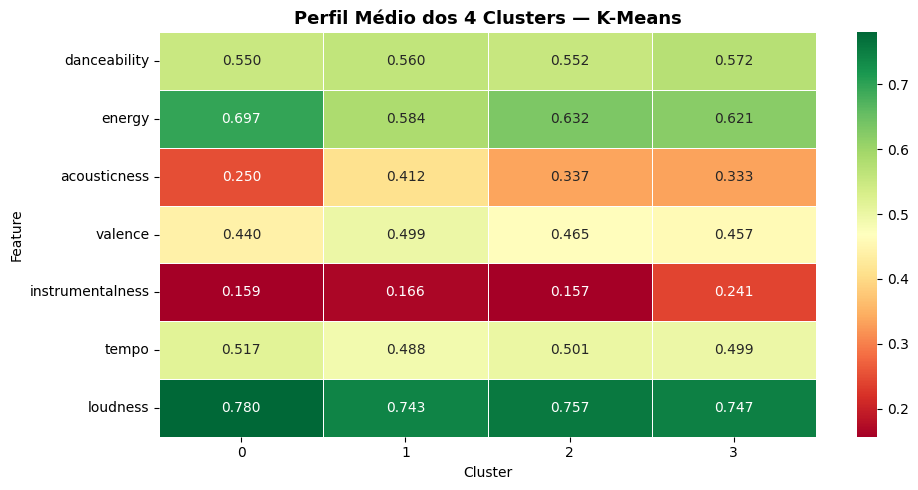

Heatmap de perfis salvo.


In [ ]:
# Perfil médio de cada cluster
features_interpretacao = ['danceability', 'energy', 'acousticness',
                           'valence', 'instrumentalness', 'tempo', 'loudness']

perfil_clusters = X_train_kmeans.groupby('cluster')[features_interpretacao].mean().round(3)
print('Perfil médio dos clusters:')
print(perfil_clusters)

# Nomes interpretados (ajuste após ver os resultados)
nomes_clusters = {
    0: 'Perfil 0',
    1: 'Perfil 1',
    2: 'Perfil 2',
    3: 'Perfil 3'
}
# Dica: após rodar, interprete cada cluster pela tabela acima e renomeie aqui.
# Exemplo: cluster com alta acousticness e baixa energy → 'Acústico/Calmo'

# Heatmap dos perfis
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(perfil_clusters.T, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, ax=ax)
ax.set_title(f'Perfil Médio dos {K_ESCOLHIDO} Clusters — K-Means', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('kmeans_perfis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap de perfis salvo.')

### Passo 4 — Visualizando os clusters (Energy vs Danceability)

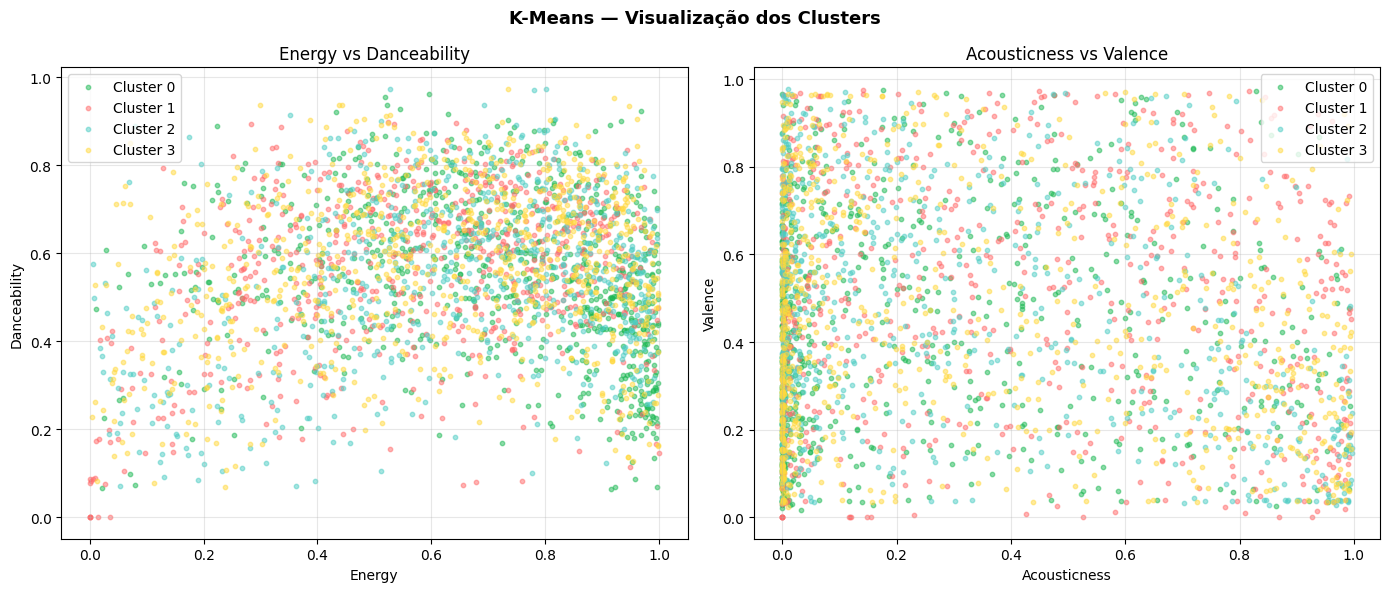

Scatter plot dos clusters salvo.


In [ ]:
# Scatter plot dos clusters
cores = ['#1DB954', '#FF6B6B', '#4ECDC4', '#FFD93D']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('K-Means — Visualização dos Clusters', fontsize=13, fontweight='bold')

# Energy vs Danceability
amostra_viz = X_train_kmeans.sample(3000, random_state=42)
for cluster_id in range(K_ESCOLHIDO):
    subset = amostra_viz[amostra_viz['cluster'] == cluster_id]
    axes[0].scatter(subset['energy'], subset['danceability'],
                    c=cores[cluster_id], label=f'Cluster {cluster_id}',
                    alpha=0.5, s=10)
axes[0].set_xlabel('Energy')
axes[0].set_ylabel('Danceability')
axes[0].set_title('Energy vs Danceability')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Acousticness vs Valence
for cluster_id in range(K_ESCOLHIDO):
    subset = amostra_viz[amostra_viz['cluster'] == cluster_id]
    axes[1].scatter(subset['acousticness'], subset['valence'],
                    c=cores[cluster_id], label=f'Cluster {cluster_id}',
                    alpha=0.5, s=10)
axes[1].set_xlabel('Acousticness')
axes[1].set_ylabel('Valence')
axes[1].set_title('Acousticness vs Valence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scatter plot dos clusters salvo.')

### Resultado do K-Means — Resumo

In [ ]:
print('=' * 55)
print('RESULTADO — K-MEANS CLUSTERING')
print('=' * 55)
print(f'Número de clusters (K):   {K_ESCOLHIDO}')
print(f'Inércia:                  {kmeans.inertia_:.2f}')
print(f'Silhouette Score:         {sil_final:.4f}')
print()
print('Músicas por cluster:')
for c, n in X_train_kmeans['cluster'].value_counts().sort_index().items():
    print(f'  Cluster {c}: {n} músicas ({n/len(X_train_kmeans)*100:.1f}%)')
print('=' * 55)

RESULTADO — K-MEANS CLUSTERING
Número de clusters (K):   4
Inércia:                  4908257.28
Silhouette Score:         0.5432

Músicas por cluster:
  Cluster 0: 16551 músicas (25.5%)
  Cluster 1: 13993 músicas (21.5%)
  Cluster 2: 15456 músicas (23.8%)
  Cluster 3: 18952 músicas (29.2%)


---
---
#ALGORITMO 2 — Árvore de Decisão
### Família: Classificação (supervisionado)

---
## O que é a Árvore de Decisão?
A Árvore de Decisão é um algoritmo **supervisionado de classificação** — aprende a partir de exemplos rotulados.  
Ela cria uma estrutura em forma de árvore com **perguntas sobre os atributos** da música, chegando a uma classificação final.

### Por que usar no nosso problema?
Queremos responder: *"Quais atributos sonoros melhor classificam uma música como Obscura, Em Ascensão, Mainstream ou Hit?"*

### Como funciona?
1. Escolhe a feature que melhor **divide** os dados (maior ganho de informação / menor Gini)
2. Cria um nó de decisão com essa pergunta
3. Repete recursivamente até atingir profundidade máxima ou pureza

### Variável-alvo (Target)
| Código | Categoria | Popularidade |
|---|---|---|
| 0 | Obscura | 0–25 |
| 1 | Em Ascensão | 26–50 |
| 2 | Mainstream | 51–75 |
| 3 | Hit | 76–100 |

### Métricas de avaliação
- **Acurácia:** % de músicas classificadas corretamente
- **Precisão:** das que previu como Hit, quantas eram Hit de fato?
- **Recall:** das músicas Hit reais, quantas o modelo encontrou?
- **F1-Score:** média harmônica entre precisão e recall

### Passo 1 — Treinando a Árvore de Decisão
Controlamos a profundidade máxima (`max_depth`) para evitar **overfitting** — quando o modelo decora os dados de treino mas vai mal nos dados de teste.

In [ ]:
# Encontrando a profundidade ideal testando diferentes valores
print('Testando profundidades...')
print(f'{"Profundidade":<15} {"Acurácia Treino":<20} {"Acurácia Teste"}')
print('-' * 50)

resultados_depth = []
for depth in [3, 5, 7, 10, 15, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_clf_train)
    acc_treino = dt.score(X_train, y_clf_train)
    acc_teste  = dt.score(X_test, y_clf_test)
    resultados_depth.append({'depth': str(depth), 'treino': acc_treino, 'teste': acc_teste})
    print(f'{str(depth):<15} {acc_treino:.4f}              {acc_teste:.4f}')

print('\nObservação: quando a acurácia de treino é muito maior que a de teste → overfitting.')

Testando profundidades...
Profundidade    Acurácia Treino      Acurácia Teste
--------------------------------------------------
3               0.4922              0.4997
5               0.5331              0.5383
7               0.5701              0.5702
10              0.6416              0.6148
15              0.7824              0.6261
None            0.9985              0.5983

Observação: quando a acurácia de treino é muito maior que a de teste → overfitting.


In [ ]:
# Treinando com a profundidade escolhida
# Decisão: max_depth=7 — bom equilíbrio entre aprendizado e generalização
MAX_DEPTH = 7

arvore = DecisionTreeClassifier(
    max_depth=MAX_DEPTH,
    criterion='gini',       # impureza de Gini para escolher os splits
    min_samples_split=20,   # mínimo de amostras para dividir um nó
    min_samples_leaf=10,    # mínimo de amostras em cada folha
    random_state=42
)
arvore.fit(X_train, y_clf_train)

# Predições
y_pred_clf = arvore.predict(X_test)

print(f'Árvore de Decisão treinada!')
print(f'   Profundidade máxima: {MAX_DEPTH}')
print(f'   Nós gerados:         {arvore.tree_.node_count}')
print(f'   Features usadas:     {arvore.n_features_in_}')

Árvore de Decisão treinada!
   Profundidade máxima: 7
   Nós gerados:         235
   Features usadas:     15


### Passo 2 — Avaliando o desempenho

In [ ]:
# Métricas de desempenho
acc   = accuracy_score(y_clf_test, y_pred_clf)
prec  = precision_score(y_clf_test, y_pred_clf, average='weighted', zero_division=0)
rec   = recall_score(y_clf_test, y_pred_clf, average='weighted', zero_division=0)
f1    = f1_score(y_clf_test, y_pred_clf, average='weighted', zero_division=0)

print('=' * 45)
print('MÉTRICAS — ÁRVORE DE DECISÃO')
print('=' * 45)
print(f'Acurácia:   {acc:.4f}  ({acc*100:.1f}%)')
print(f'Precisão:   {prec:.4f}')
print(f'Recall:     {rec:.4f}')
print(f'F1-Score:   {f1:.4f}')
print('=' * 45)
print()
print('Relatório completo por classe:')
nomes_classes = ['Obscura (0)', 'Em Ascensão (1)', 'Mainstream (2)', 'Hit (3)']
print(classification_report(y_clf_test, y_pred_clf, target_names=nomes_classes, zero_division=0))

MÉTRICAS — ÁRVORE DE DECISÃO
Acurácia:   0.5705  (57.1%)
Precisão:   0.5596
Recall:     0.5705
F1-Score:   0.5230

Relatório completo por classe:
                 precision    recall  f1-score   support

    Obscura (0)       0.63      0.64      0.63      5655
Em Ascensão (1)       0.54      0.78      0.64      6829
 Mainstream (2)       0.53      0.09      0.16      3502
        Hit (3)       0.00      0.00      0.00       253

       accuracy                           0.57     16239
      macro avg       0.42      0.38      0.36     16239
   weighted avg       0.56      0.57      0.52     16239



### Passo 3 — Validação Cruzada (5-fold)
A validação cruzada testa o modelo em 5 divisões diferentes do dataset, garantindo que o resultado não depende de uma divisão específica.

In [ ]:
# Validação cruzada 5-fold
scores_cv = cross_val_score(arvore, X_train, y_clf_train, cv=5, scoring='accuracy')

print('Validação Cruzada — 5-Fold:')
for i, score in enumerate(scores_cv, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\nMédia:  {scores_cv.mean():.4f}')
print(f'Desvio: {scores_cv.std():.4f}')
print('\n(Desvio baixo = modelo estável e generalizável)')

Validação Cruzada — 5-Fold:
  Fold 1: 0.5639
  Fold 2: 0.5592
  Fold 3: 0.5651
  Fold 4: 0.5671
  Fold 5: 0.5628

Média:  0.5636
Desvio: 0.0026

(Desvio baixo = modelo estável e generalizável)


### Passo 4 — Matriz de Confusão e Importância das Features

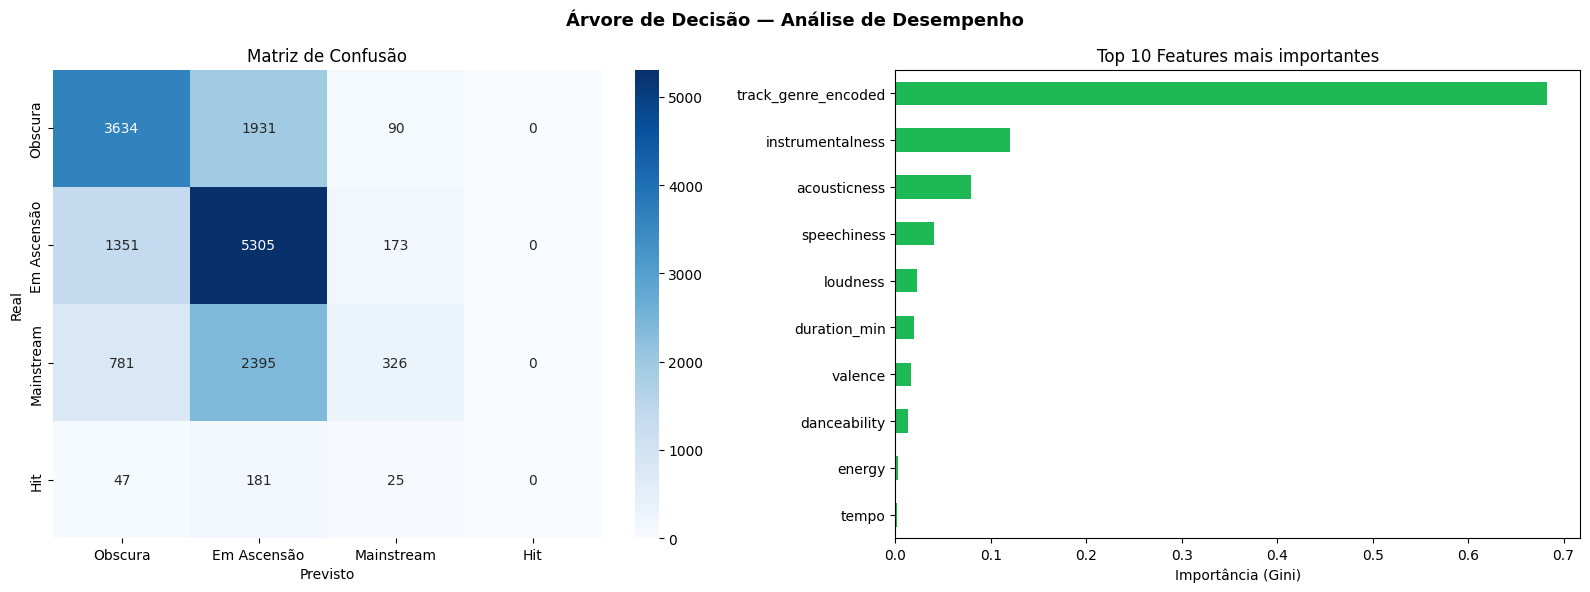

Gráficos de desempenho salvos.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Árvore de Decisão — Análise de Desempenho', fontsize=13, fontweight='bold')

# Matriz de Confusão
cm = confusion_matrix(y_clf_test, y_pred_clf)
rotulos = ['Obscura', 'Em Ascensão', 'Mainstream', 'Hit']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rotulos, yticklabels=rotulos, ax=axes[0])
axes[0].set_title('Matriz de Confusão')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

# Importância das Features
importancias = pd.Series(arvore.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=True).tail(10)
importancias.plot(kind='barh', ax=axes[1], color='#1DB954')
axes[1].set_title('Top 10 Features mais importantes')
axes[1].set_xlabel('Importância (Gini)')

plt.tight_layout()
plt.savefig('arvore_desempenho.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráficos de desempenho salvos.')

### Passo 5 — Visualizando a Árvore de Decisão (primeiros 3 níveis)

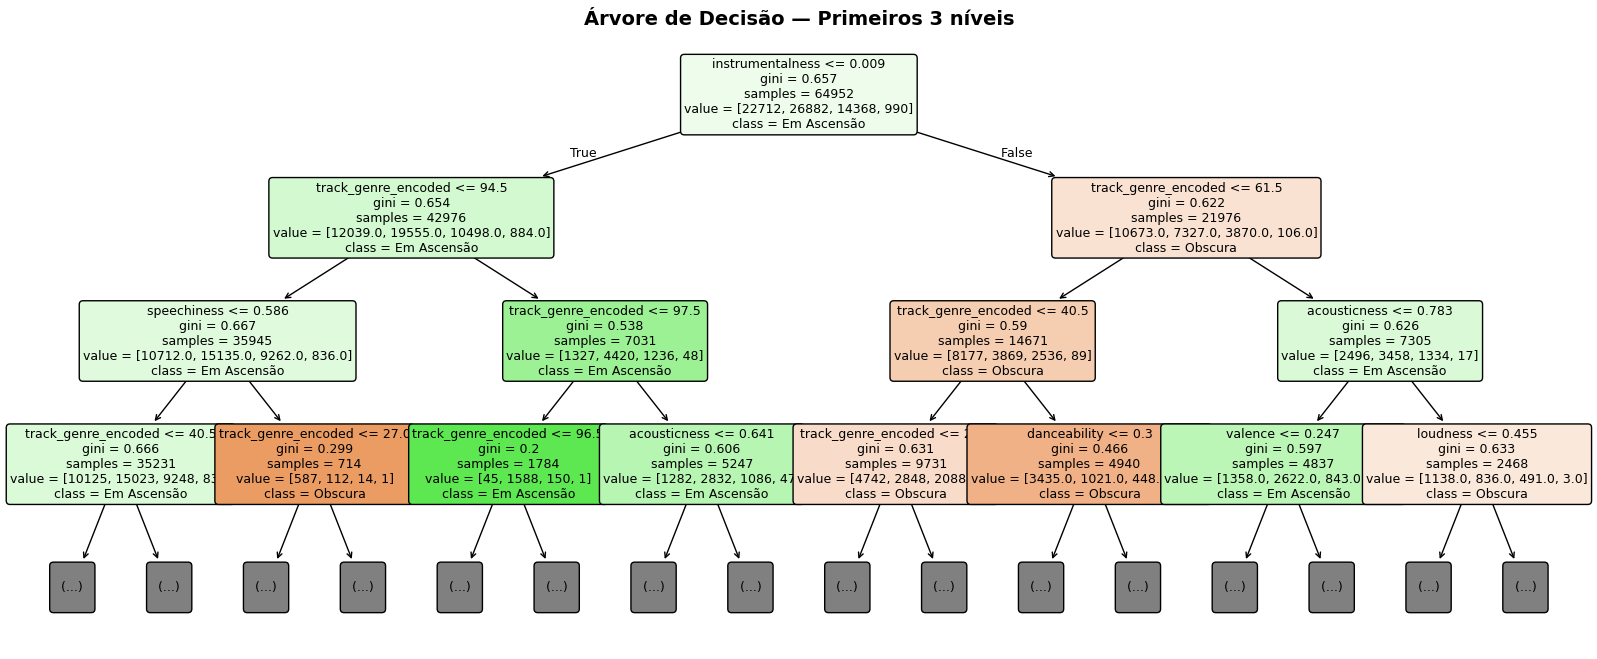

Visualização da árvore salva.


In [ ]:
# Visualização da árvore (limitada a 3 níveis para legibilidade)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    arvore,
    max_depth=3,
    feature_names=X_train.columns,
    class_names=['Obscura', 'Em Ascensão', 'Mainstream', 'Hit'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Árvore de Decisão — Primeiros 3 níveis', fontsize=14, fontweight='bold')
plt.savefig('arvore_visualizacao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualização da árvore salva.')

### Resultado da Árvore de Decisão — Resumo

In [ ]:
print('=' * 55)
print('RESULTADO — ÁRVORE DE DECISÃO')
print('=' * 55)
print(f'Profundidade máxima:    {MAX_DEPTH}')
print(f'Acurácia no teste:      {acc:.4f} ({acc*100:.1f}%)')
print(f'Precisão (weighted):    {prec:.4f}')
print(f'Recall (weighted):      {rec:.4f}')
print(f'F1-Score (weighted):    {f1:.4f}')
print(f'Cross-val (5-fold):     {scores_cv.mean():.4f} ± {scores_cv.std():.4f}')
print()
print('Feature mais importante:')
top_feature = importancias.idxmax()
print(f'  → {top_feature} ({importancias.max():.4f})')
print('=' * 55)

RESULTADO — ÁRVORE DE DECISÃO
Profundidade máxima:    7
Acurácia no teste:      0.5705 (57.1%)
Precisão (weighted):    0.5596
Recall (weighted):      0.5705
F1-Score (weighted):    0.5230
Cross-val (5-fold):     0.5636 ± 0.0026

Feature mais importante:
  → track_genre_encoded (0.6831)


---
---
#ALGORITMO 3 — Regressão Linear
### Família: Regressão (supervisionado)

---
## O que é a Regressão Linear?
A Regressão Linear é um algoritmo **supervisionado de regressão** — prevê um **valor numérico contínuo**, não uma categoria.  
Ela encontra a equação linear que melhor descreve a relação entre as features e a popularidade.

### Por que usar no nosso problema?
Queremos responder: *"Dado os atributos sonoros de uma música, qual será seu score de popularidade (0–100)?"*  
Diferente da Árvore de Decisão (que classifica em 4 categorias), a Regressão prevê o valor exato.

### Como funciona?
Encontra os coeficientes (pesos) de cada feature que minimizam o erro quadrático médio:  
`popularidade = w1*danceability + w2*energy + w3*loudness + ... + b`

### Métricas de avaliação
- **R² (R-quadrado):** % da variância da popularidade explicada pelo modelo (0 a 1, maior = melhor)
- **MAE (Erro Absoluto Médio):** em média, quantos pontos o modelo erra na previsão
- **RMSE (Raiz do Erro Quadrático Médio):** penaliza erros grandes, mais sensível a outliers

### Passo 1 — Treinando a Regressão Linear

In [ ]:
# Treinando o modelo de Regressão Linear
regressao = LinearRegression()
regressao.fit(X_train, y_reg_train)

# Predições
y_pred_reg = regressao.predict(X_test)

# Limitando predições ao intervalo válido [0, 100]
y_pred_reg = np.clip(y_pred_reg, 0, 100)

print('Regressão Linear treinada!')
print(f'   Features usadas: {regressao.n_features_in_}')
print(f'   Intercepto (b):  {regressao.intercept_:.4f}')

Regressão Linear treinada!
   Features usadas: 15
   Intercepto (b):  0.3327


### Passo 2 — Avaliando o desempenho

In [ ]:
# Métricas de regressão
r2   = r2_score(y_reg_test, y_pred_reg)
mae  = mean_absolute_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))

# No treino (para detectar overfitting)
y_pred_treino = np.clip(regressao.predict(X_train), 0, 100)
r2_treino = r2_score(y_reg_train, y_pred_treino)

print('=' * 45)
print('MÉTRICAS — REGRESSÃO LINEAR')
print('=' * 45)
print(f'R² (teste):    {r2:.4f}  ({r2*100:.1f}% da variância explicada)')
print(f'R² (treino):   {r2_treino:.4f}')
print(f'MAE:           {mae:.4f}  (erro médio de {mae:.1f} pontos)')
print(f'RMSE:          {rmse:.4f}')
print('=' * 45)
print()
print('Interpretação do R²:')
if r2 >= 0.7:
    print('  Bom — o modelo explica bem a popularidade')
elif r2 >= 0.4:
    print('  Moderado — atributos sonoros explicam parte da popularidade')
else:
    print('  Baixo — outros fatores além do som influenciam a popularidade')
    print('  (fama do artista, marketing, algoritmo do Spotify, etc.)')

MÉTRICAS — REGRESSÃO LINEAR
R² (teste):    0.0654  (6.5% da variância explicada)
R² (treino):   0.0641
MAE:           0.1516  (erro médio de 0.2 pontos)
RMSE:          0.1862

Interpretação do R²:
  Baixo — outros fatores além do som influenciam a popularidade
  (fama do artista, marketing, algoritmo do Spotify, etc.)


### Passo 3 — Validação Cruzada (5-fold)

In [ ]:
# Validação cruzada 5-fold
scores_reg_cv = cross_val_score(regressao, X_train, y_reg_train, cv=5, scoring='r2')

print('Validação Cruzada — 5-Fold (R²):')
for i, score in enumerate(scores_reg_cv, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\nMédia:  {scores_reg_cv.mean():.4f}')
print(f'Desvio: {scores_reg_cv.std():.4f}')

Validação Cruzada — 5-Fold (R²):
  Fold 1: 0.0646
  Fold 2: 0.0613
  Fold 3: 0.0598
  Fold 4: 0.0673
  Fold 5: 0.0636

Média:  0.0633
Desvio: 0.0026


### Passo 4 — Visualizações da Regressão

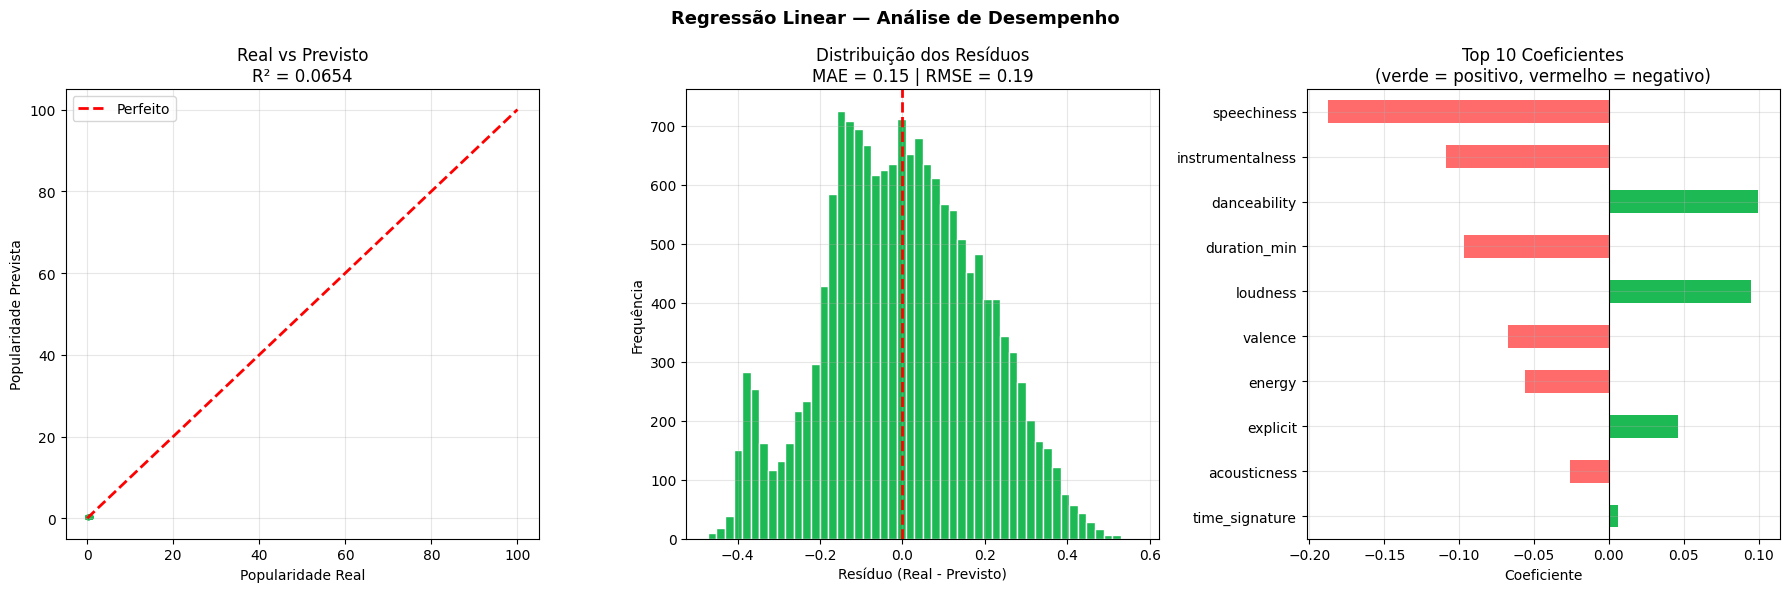

Gráficos de regressão salvos.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Regressão Linear — Análise de Desempenho', fontsize=13, fontweight='bold')

# 1. Real vs Previsto
amostra_idx = np.random.choice(len(y_reg_test), 2000, replace=False)
axes[0].scatter(y_reg_test.iloc[amostra_idx], y_pred_reg[amostra_idx],
                alpha=0.3, s=5, color='#1DB954')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfeito')
axes[0].set_xlabel('Popularidade Real')
axes[0].set_ylabel('Popularidade Prevista')
axes[0].set_title(f'Real vs Previsto\nR² = {r2:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Distribuição dos resíduos
residuos = y_reg_test.values - y_pred_reg
axes[1].hist(residuos, bins=50, color='#1DB954', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Resíduo (Real - Previsto)')
axes[1].set_ylabel('Frequência')
axes[1].set_title(f'Distribuição dos Resíduos\nMAE = {mae:.2f} | RMSE = {rmse:.2f}')
axes[1].grid(True, alpha=0.3)

# 3. Coeficientes das features
coefs = pd.Series(regressao.coef_, index=X_train.columns)
coefs_sorted = coefs.abs().sort_values(ascending=True).tail(10)
coefs_top = coefs[coefs_sorted.index]
cores_coef = ['#FF6B6B' if v < 0 else '#1DB954' for v in coefs_top.values]
coefs_top.plot(kind='barh', ax=axes[2], color=cores_coef)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Top 10 Coeficientes\n(verde = positivo, vermelho = negativo)')
axes[2].set_xlabel('Coeficiente')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regressao_desempenho.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráficos de regressão salvos.')

### Resultado da Regressão Linear — Resumo

In [ ]:
print('=' * 55)
print('RESULTADO — REGRESSÃO LINEAR')
print('=' * 55)
print(f'R² no teste:            {r2:.4f} ({r2*100:.1f}%)')
print(f'R² no treino:           {r2_treino:.4f}')
print(f'MAE:                    {mae:.4f} pontos de erro médio')
print(f'RMSE:                   {rmse:.4f}')
print(f'Cross-val R² (5-fold):  {scores_reg_cv.mean():.4f} ± {scores_reg_cv.std():.4f}')
print()
print('Feature com maior impacto positivo:')
print(f'  → {coefs.idxmax()} ({coefs.max():.4f})')
print('Feature com maior impacto negativo:')
print(f'  → {coefs.idxmin()} ({coefs.min():.4f})')
print('=' * 55)

RESULTADO — REGRESSÃO LINEAR
R² no teste:            0.0654 (6.5%)
R² no treino:           0.0641
MAE:                    0.1516 pontos de erro médio
RMSE:                   0.1862
Cross-val R² (5-fold):  0.0633 ± 0.0026

Feature com maior impacto positivo:
  → danceability (0.0999)
Feature com maior impacto negativo:
  → speechiness (-0.1875)


---
---
#COMPARAÇÃO FINAL DOS 3 ALGORITMOS


In [ ]:
print('=' * 65)
print('COMPARAÇÃO FINAL DOS 3 ALGORITMOS')
print('=' * 65)
print(f'{'Algoritmo':<25} {'Tipo':<20} {'Métrica Principal':<20} Valor')
print('-' * 65)
print(f'{'K-Means Clustering':<25} {'Agrupamento':<20} {'Silhouette Score':<20} {sil_final:.4f}')
print(f'{'Árvore de Decisão':<25} {'Classificação':<20} {'Acurácia':<20} {acc:.4f}')
print(f'{'Regressão Linear':<25} {'Regressão':<20} {'R²':<20} {r2:.4f}')
print('=' * 65)

COMPARAÇÃO FINAL DOS 3 ALGORITMOS
Algoritmo                 Tipo                 Métrica Principal    Valor
-----------------------------------------------------------------
K-Means Clustering        Agrupamento          Silhouette Score     0.5432
Árvore de Decisão         Classificação        Acurácia             0.5705
Regressão Linear          Regressão            R²                   0.0654


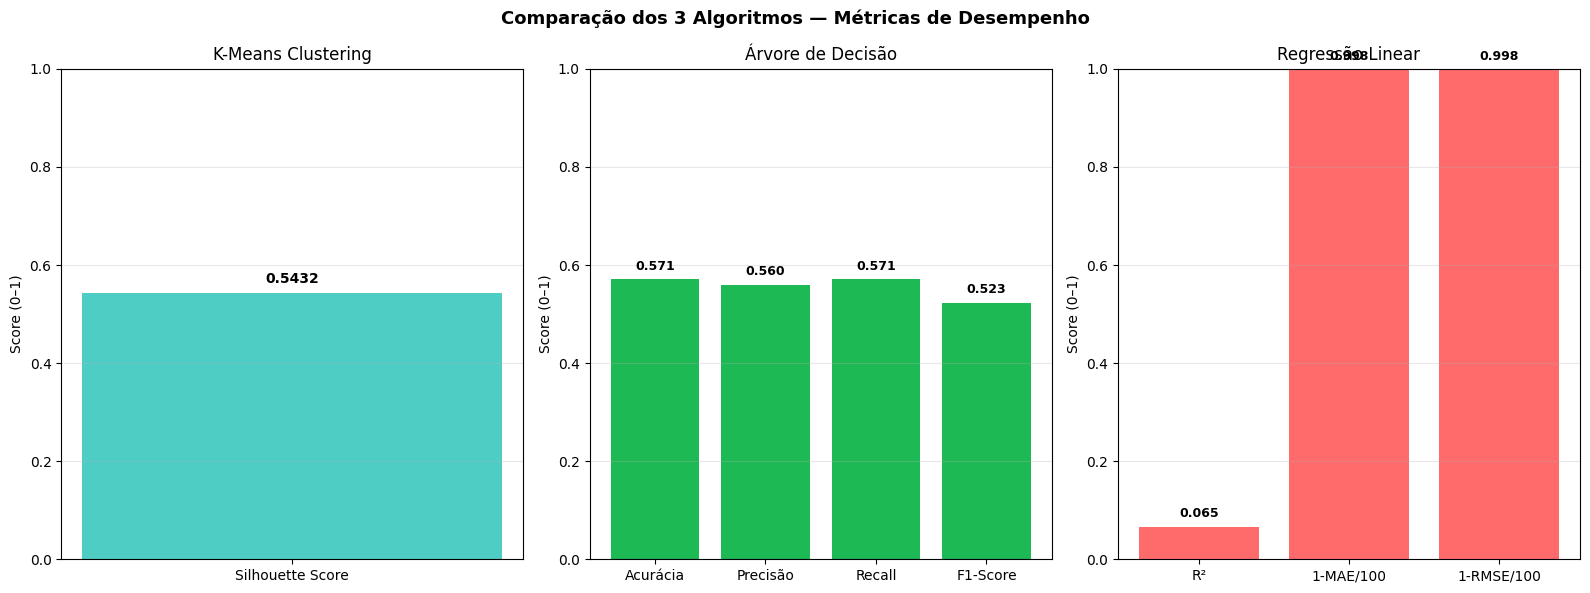

Gráfico comparativo salvo.


In [ ]:
# Gráfico comparativo das métricas normalizadas
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Comparação dos 3 Algoritmos — Métricas de Desempenho',
             fontsize=13, fontweight='bold')

# K-Means: Silhouette
axes[0].bar(['Silhouette Score'], [sil_final], color='#4ECDC4', width=0.4)
axes[0].set_ylim(0, 1)
axes[0].set_title('K-Means Clustering')
axes[0].set_ylabel('Score (0–1)')
axes[0].text(0, sil_final + 0.02, f'{sil_final:.4f}', ha='center', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Árvore de Decisão: métricas
metricas_arvore = [acc, prec, rec, f1]
nomes_arvore    = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
bars = axes[1].bar(nomes_arvore, metricas_arvore, color='#1DB954')
axes[1].set_ylim(0, 1)
axes[1].set_title('Árvore de Decisão')
axes[1].set_ylabel('Score (0–1)')
for bar, val in zip(bars, metricas_arvore):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Regressão: R², MAE normalizado, RMSE normalizado
mae_norm  = 1 - (mae / 100)   # normalizado: MAE menor = melhor
rmse_norm = 1 - (rmse / 100)
metricas_reg = [r2, mae_norm, rmse_norm]
nomes_reg    = ['R²', '1-MAE/100', '1-RMSE/100']
bars2 = axes[2].bar(nomes_reg, metricas_reg, color='#FF6B6B')
axes[2].set_ylim(0, 1)
axes[2].set_title('Regressão Linear')
axes[2].set_ylabel('Score (0–1)')
for bar, val in zip(bars2, metricas_reg):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('comparacao_algoritmos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico comparativo salvo.')

---
## Salvando todos os resultados da Fase 3 no Drive

In [ ]:
import shutil

PASTA_RESULTADOS = '/content/drive/MyDrive/A3 2026/Resultados Algoritimos'

arquivos_fase3 = [
    'kmeans_cotovelo.png',
    'kmeans_perfis.png',
    'kmeans_scatter.png',
    'arvore_desempenho.png',
    'arvore_visualizacao.png',
    'regressao_desempenho.png',
    'comparacao_algoritmos.png'
]

for arquivo in arquivos_fase3:
    try:
        shutil.copy(arquivo, f'{PASTA_RESULTADOS}/{arquivo}')
        print(f'{arquivo} salvo no Drive')
    except Exception as e:
        print(f'{arquivo} não encontrado: {e}')

print('\n Todos os resultados salvos na pasta Resultados.')

kmeans_cotovelo.png salvo no Drive
kmeans_perfis.png salvo no Drive
kmeans_scatter.png salvo no Drive
arvore_desempenho.png salvo no Drive
arvore_visualizacao.png salvo no Drive
regressao_desempenho.png salvo no Drive
comparacao_algoritmos.png salvo no Drive

 Todos os resultados salvos na pasta Resultados.


---
##Resumo

| Algoritmo | Família (Edital) | Métrica | Resultado |
|---|---|---|---|
| K-Means Clustering | Agrupamento | Silhouette Score | *ver acima* |
| Árvore de Decisão | Classificação | Acurácia / F1 | *ver acima* |
| Regressão Linear | Regressão | R² / MAE | *ver acima* |

### Arquivos gerados (para o relatório e apresentação)
| Arquivo | Conteúdo |
|---|---|
| `kmeans_cotovelo.png` | Método do cotovelo para escolha do K |
| `kmeans_perfis.png` | Heatmap dos perfis sonoros de cada cluster |
| `kmeans_scatter.png` | Visualização dos clusters no espaço 2D |
| `arvore_desempenho.png` | Matriz de confusão + importância das features |
| `arvore_visualizacao.png` | Estrutura visual da árvore (3 primeiros níveis) |
| `regressao_desempenho.png` | Real vs Previsto + resíduos + coeficientes |
| `comparacao_algoritmos.png` | Gráfico comparativo dos 3 algoritmos |
.